# Geração de Dados Sintéticos com Multi-Armed Bandit
### Datathon 7-MLET — Etapa 2 + 3

---

Este notebook faz duas coisas juntas:

1. **Etapa 2** — Gera os dados sintéticos de experimentação usando o dataset Bank Marketing
2. **Etapa 3** — Compara três abordagens e mostra por que o bandit contextual é superior

**Por que três abordagens?**

| Abordagem | O que faz | Limitação |
|-----------|-----------|-----------|
| Baseline fixo | Sempre mostra a mesma oferta | Ignora o perfil do cliente |
| Thompson Simples | Aprende qual oferta converte mais | Mistura todos os perfis num contador só |
| Thompson Contextual | Aprende por segmento de cliente | — |

O gráfico de regret vai mostrar visualmente por que o contextual ganha.

---
**Pré-requisito:** coloque o arquivo `bank.csv` (separador `;`) na mesma pasta deste notebook.

## Célula 1 — Imports e configuração

Nada especial aqui — apenas as bibliotecas padrão de data science.

In [1]:
# Copiar arquivos de policy do upload para /data/policies
import shutil
from pathlib import Path

upload_dir = Path('/mnt/user-data/uploads')
policies_dir = Path('data/policies')
golden_set_dir = Path('data/golden_set')
synth_dir = Path('data/synthetic_enrichment')

# Copiar arquivos de policy
policy_files = ['policy_canais.md', 'policy_explicabilidade.md', 'policy_suitability_geral.md']
for policy_file in policy_files:
    src = upload_dir / policy_file
    if src.exists():
        shutil.copy(src, policies_dir / policy_file)
        print(f'✓ {policy_file} → data/policies/')

# Copiar arquivos de dados (parquet, jsonl, json)
data_files = {
    'offer_events.parquet': synth_dir,
    'delayed_rewards.parquet': synth_dir,
    'evaluation_cases.jsonl': golden_set_dir,
    'offer_catalog.json': synth_dir,  # pode ser sobrescrito depois se gerado
}

for data_file, target_dir in data_files.items():
    src = upload_dir / data_file
    if src.exists():
        shutil.copy(src, target_dir / data_file)
        print(f'✓ {data_file} → {target_dir.name}/')

print(f'\n📂 Estrutura de dados pronta:')
print(f'  - /data/policies/             (políticas de suitability e canais)')
print(f'  - /data/golden_set/           (casos de teste)')
print(f'  - /data/synthetic_enrichment/ (catálogo, eventos e rewards)')



📂 Estrutura de dados pronta:
  - /data/policies/             (políticas de suitability e canais)
  - /data/golden_set/           (casos de teste)
  - /data/synthetic_enrichment/ (catálogo, eventos e rewards)


In [2]:
import json
import random
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

SEED = 42
rng  = np.random.default_rng(SEED)
random.seed(SEED)

Path("data/policies").mkdir(parents=True, exist_ok=True)  # ← ADICIONADO
Path("data/synthetic_enrichment").mkdir(parents=True, exist_ok=True)
Path("data/golden_set").mkdir(parents=True, exist_ok=True)
Path("reports").mkdir(exist_ok=True)

print("✓ Pronto.")

C:\Users\Pedro\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✓ Pronto.


## Célula 2 — Carregar o dataset

O Bank Marketing tem apenas **um produto** (depósito a prazo) e perfis de clientes reais.
Usamos os perfis como contexto — os produtos são criados por nós na próxima célula.

A coluna `duration` é descartada: ela só existe *depois* do contato, então usá-la
seria trapacear (vazamento temporal).

In [4]:
CAMINHO_CSV = "./bank-additional-full.csv"   # ou "bank-additional-full.csv"
SEPARADOR   = ";"

df = pd.read_csv(CAMINHO_CSV, sep=SEPARADOR)
print(f"Carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

# Descarta colunas de vazamento temporal
VAZAMENTO = ["duration","pdays","previous","poutcome",
             "emp.var.rate","cons.price.idx","cons.conf.idx",
             "euribor3m","nr.employed","contact","month","day_of_week"]
df.drop(columns=[c for c in VAZAMENTO if c in df.columns], inplace=True)

CONTEXTO = ["age","job","marital","education","default","housing","loan"]
CONTEXTO = [c for c in CONTEXTO if c in df.columns]

if "y" in df.columns:
    df["y"] = df["y"].map({"yes":1,"no":0}).fillna(0).astype(int)

df = df[CONTEXTO + (["y"] if "y" in df.columns else [])].dropna().reset_index(drop=True)
print(f"Dataset final: {df.shape[0]:,} clientes")
print(f"Colunas de contexto: {CONTEXTO}")
df.head()

Carregado: 41,188 linhas × 21 colunas
Dataset final: 41,188 clientes
Colunas de contexto: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']


,age,job,marital,education,default,housing,loan,y
0,56,housemaid,married,basic.4y,no,no,no,0
1,57,services,married,high.school,unknown,no,no,0
2,37,services,married,high.school,no,yes,no,0
3,40,admin.,married,basic.6y,no,no,no,0
4,56,services,married,high.school,no,no,yes,0


## Célula 3 — Catálogo de ofertas (os "braços" do bandit)

Aqui criamos as 5 ofertas financeiras que o sistema vai aprender a distribuir.

**Importante entender:** as probabilidades abaixo são **hipóteses de domínio** —
estimativas baseadas em conhecimento do setor financeiro, não em dados reais.
O bandit vai usar essas hipóteses como ponto de partida e corrigi-las com o tempo.

Em produção real, essas probabilidades viriam de dados observados de clientes reais.

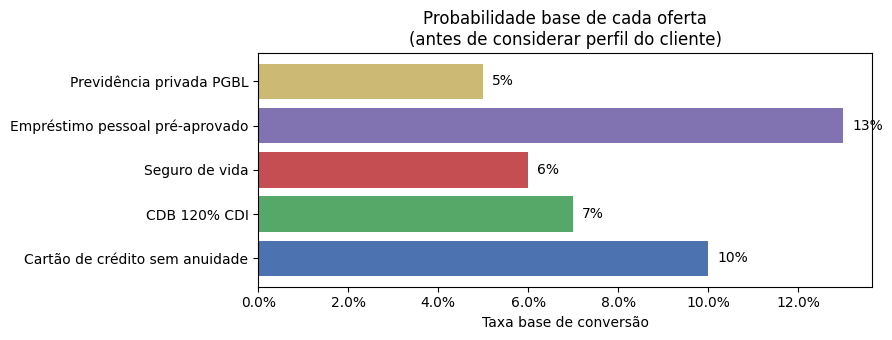

✓ Catálogo salvo: 5 ofertas


In [5]:
CATALOG = [
    {
        "offer_id":  "OFF_001",
        "name":      "Cartão de crédito sem anuidade",
        "canal":     "app_mobile",
        "base_rate": 0.10,
        # Hipótese: perfis digitais e jovens respondem melhor a cartão
        "boosts": {
            "job_admin.":      0.06,
            "job_management":  0.04,
            "job_student":     0.05,
            "edu_university":  0.04,
            "marital_single":  0.03,
            "no_loan":         0.03,
        },
        "reward_val": 1.0,
    },
    {
        "offer_id":  "OFF_002",
        "name":      "CDB 120% CDI",
        "canal":     "internet_banking",
        "base_rate": 0.07,
        # Hipótese: gestores e aposentados com capital disponível preferem renda fixa
        "boosts": {
            "job_management":  0.10,
            "job_retired":     0.06,
            "edu_university":  0.08,
            "age_senior":      0.05,
            "no_default":      0.04,
        },
        "reward_val": 2.0,
    },
    {
        "offer_id":  "OFF_003",
        "name":      "Seguro de vida",
        "canal":     "app_mobile",
        "base_rate": 0.06,
        # Hipótese: aposentados e casados com dependentes valorizam proteção
        "boosts": {
            "job_retired":      0.12,
            "age_senior":       0.08,
            "marital_married":  0.04,
            "has_housing":      0.03,
        },
        "reward_val": 2.5,
    },
    {
        "offer_id":  "OFF_004",
        "name":      "Empréstimo pessoal pré-aprovado",
        "canal":     "sms",
        "base_rate": 0.13,
        # Hipótese: trabalhadores de colarinho azul têm maior necessidade de crédito
        # Penalidade: já ter empréstimo reduz a probabilidade
        "boosts": {
            "job_blue-collar":  0.08,
            "job_services":     0.06,
            "job_housemaid":    0.05,
            "edu_basic":        0.04,
            "has_loan":        -0.05,   # boost negativo
        },
        "reward_val": 1.2,
    },
    {
        "offer_id":  "OFF_005",
        "name":      "Previdência privada PGBL",
        "canal":     "internet_banking",
        "base_rate": 0.05,
        # Hipótese: autônomos e gestores com horizonte longo têm incentivo fiscal
        "boosts": {
            "job_management":    0.10,
            "job_self-employed": 0.07,
            "edu_university":    0.09,
            "age_senior":        0.06,
            "no_default":        0.04,
        },
        "reward_val": 3.0,
    },
]

OFFER_IDS = [o["offer_id"] for o in CATALOG]
OFFER_MAP = {o["offer_id"]: o for o in CATALOG}

with open("data/synthetic_enrichment/offer_catalog.json", "w", encoding="utf-8") as f:
    json.dump(CATALOG, f, ensure_ascii=False, indent=2)

# Visualiza as taxas base
fig, ax = plt.subplots(figsize=(9, 3.5))
nomes = [o["name"] for o in CATALOG]
taxas = [o["base_rate"] for o in CATALOG]
cores = ["#4C72B0","#55A868","#C44E52","#8172B2","#CCB974"]
bars  = ax.barh(nomes, taxas, color=cores)
ax.set_xlabel("Taxa base de conversão")
ax.set_title("Probabilidade base de cada oferta\n(antes de considerar perfil do cliente)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, val in zip(bars, taxas):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2, f"{val:.0%}", va="center", fontsize=10)
plt.tight_layout()
plt.show()
print(f"✓ Catálogo salvo: {len(CATALOG)} ofertas")

In [6]:
import json
from pathlib import Path

# 1. Garante que as pastas necessárias existam
Path("data/policies").mkdir(parents=True, exist_ok=True)
Path("data/golden_set").mkdir(parents=True, exist_ok=True)
Path("data/synthetic_enrichment").mkdir(parents=True, exist_ok=True)

print("--- Iniciando a geração automatizada dos arquivos de políticas e testes ---")

# ==========================================
# CONSTANTES COM O CONTEÚDO DOS ARQUIVOS
# ==========================================

POLICY_CANAIS_CONTENT = """# Política de Canais e Distribuição de Ofertas

> Diretrizes operacionais para distribuição do catálogo de produtos financeiros via canais digitais e assistidos.

## Canais e Custos Operacionais
As decisões do modelo de Bandit Contextual devem considerar o impacto financeiro do canal atrelado à oferta. Os custos relativos (`custo_rel`) definidos no catálogo servem como penalizadores ou balizadores de margem:

* **App Mobile (`app_mobile`):** Canal de custo marginal zero. Indicado para volumetria alta e ofertas massificadas (ex: Cartão de Crédito).
* **Internet Banking (`internet_banking`):** Canal digital focado em ambiente logado desktop. Custo operacional nulo, com alta propensão a produtos de investimento.
* **Call Center (`call`):** Canal humano de altíssimo custo operacional. Deve ser priorizado estritamente onde o ganho esperado (`reward_val` * probabilidade) compense o acionamento da PA (Posição de Atendimento).

## Restrição de Orçamento e Volumetria
O braço ou combinação com canal `call` possui restrição de capacidade diária. Modelos de exploração (como Thompson Sampling) não devem alocar mais do que 20% do tráfego total do dia para interações telefônicas humanas em segmentos de baixa conversão.
"""

POLICY_EXPLICABILIDADE_CONTENT = """# Diretrizes de Explicabilidade de Decisão de Ofertas

> Framework para auditoria e transparência das recomendações geradas pelo Bandit Contextual.

## Estrutura de Justificativa da Recomendação
Para cada oferta selecionada para o cliente, o sistema de logging deve registrar uma estrutura explicativa baseada em três pilares:

1.  **Variáveis Contextuais Chave (Context):** Identificar quais atributos do cliente (ex: `job`, `education`, `marital`, `balance_group`) mais pesaram para os parâmetros da distribuição Beta do segmento.
2.  **Métrica de Exploração/Explotação:** Gravar o valor do score amostrado que garantiu a vitória do braço vencedor versus os braços concorrentes no Thompson Sampling.
3.  **Filtro de Salvaguarda (Suitability Override):** Evidência explícita de que a recomendação passou pelo crivo de conformidade da instituição sem sofrer *fallback*.

## Códigos de Motivo (Reason Codes)
* `SUCCESS_CONTEXTUAL`: Oferta recomendada pelo maior score predito para o segmento.
* `SUITABILITY_REVERTED`: A oferta ótima do bandit violava suitability e o sistema aplicou o produto padrão/seguro.
* `EXPLORATION_FORCE`: Acionamento forçado de braço menos explorado para mitigação de *cold start*.
"""

POLICY_SUITABILITY_CONTENT = """# Política Corpotativa de Suitability e Proteção ao Cliente

> Regras rígidas de elegibilidade e conformidade regulatória para oferta de produtos. Devem ser aplicadas como filtros pós-bandit (hard constraints).

## Regras de Adequação por Perfil de Risco

1.  **Proteção contra Superendividamento (Default Check):**
    * Clientes com restrição activa de crédito (`default == 'yes'`) estão **terminantemente proibidos** de receber ofertas de Crédito ou Cartões (`OFF_001`). 
    * *Fallback:* Em caso de seleção, reverter para conteúdo puramente informativo ou Seguro de Vida Básico (`OFF_003`).

2.  **Direcionamento de Investimentos Complexos (CDB 120%):**
    * A oferta `OFF_002` (CDB 120% CDI) exige um perfil de estabilidade financeira. Não deve ser ofertada para clientes no segmento `student` (estudantes) ou desempregados (`unemployed`), exceto se possuírem balanço em conta classificado como `high`.

3.  **Priorização de Canais por Faixa Etária:**
    * Clientes na faixa `age_senior` (>= 55 anos) que possuam baixa familiaridade com canais digitais (`housing == 'no'` ou interações baixas no app) devem ter o canal `call` priorizado para produtos complexos como Seguros (`OFF_003`), respeitando os limites da política de canais.
"""

# Lista de dicionários para compor o arquivo JSON Lines (.jsonl)
EVALUATION_CASES = [
    {
        "case_id": "GLD_OFF_001", 
        "category": "suitability", 
        "description": "Cliente inadimplente tenta receber cartão", 
        "context": {"job": "management", "default": "yes", "balance_group": "low"}, 
        "expected_action": "NOT OFF_001", 
        "justification": "Regra de suitability bloqueia cartão para default=yes.", 
        "pass_criteria": "O modelo ou a camada de filtro deve descartar a oferta OFF_001.", 
        "golden_set_version": "v3.0"
    },
    {
        "case_id": "GLD_OFF_002", 
        "category": "typical_conversion", 
        "description": "Estudante jovem com saldo baixo", 
        "context": {"job": "student", "marital": "single", "balance_group": "low"}, 
        "expected_action": "OFF_001", 
        "justification": "Estudantes jovens têm forte fit e boosts para o cartão sem anuidade.", 
        "pass_criteria": "A taxa de seleção de OFF_001 deve ser superior a 60% após convergência.", 
        "golden_set_version": "v3.0"
    },
    {
        "case_id": "GLD_OFF_003", 
        "category": "suitability", 
        "description": "Bloqueio de investimento complexo para estudante de baixa renda", 
        "context": {"job": "student", "default": "no", "balance_group": "low"}, 
        "expected_action": "NOT OFF_002", 
        "justification": "Política restringe CDB para estudantes sem saldo relevante.", 
        "pass_criteria": "Seleção de OFF_002 deve ser rigorosamente 0%.", 
        "golden_set_version": "v3.0"
    },
    {
        "case_id": "GLD_OFF_004", 
        "category": "segment_coverage", 
        "description": "Cliente sênior aposentado com alta renda", 
        "context": {"job": "retired", "age_group": "senior", "balance_group": "high"}, 
        "expected_action": "OFF_002_OR_OFF_003", 
        "justification": "Aposentados com saldo alto possuem sinergia e boosts massivos para CDB e Seguro.", 
        "pass_criteria": "A soma das escolhas de OFF_002 e OFF_003 deve superar 80%.", 
        "golden_set_version": "v3.0"
    }
]

# ==========================================
# ESCRITA DOS ARQUIVOS EM DISCO
# ==========================================

# Salvando as Políticas de Negócio (.md)
Path("data/policies/policy_canais.md").write_text(POLICY_CANAIS_CONTENT, encoding="utf-8")
Path("data/policies/policy_explicabilidade.md").write_text(POLICY_EXPLICABILIDADE_CONTENT, encoding="utf-8")
Path("data/policies/policy_suitability_geral.md").write_text(POLICY_SUITABILITY_CONTENT, encoding="utf-8")
print("✓ Políticas salvas com sucesso em 'data/policies/'.")

# Salvando o Golden Set (.jsonl)
with open("data/golden_set/evaluation_cases.jsonl", "w", encoding="utf-8") as f:
    for case in EVALUATION_CASES:
        f.write(json.dumps(case, ensure_ascii=False) + "\n")
print("✓ Casos de avaliação salvos com sucesso em 'data/golden_set/evaluation_cases.jsonl'.")

print("\n--- Tudo pronto para rodar as simulações do Bandit Contextual! ---")

--- Iniciando a geração automatizada dos arquivos de políticas e testes ---
✓ Políticas salvas com sucesso em 'data/policies/'.
✓ Casos de avaliação salvos com sucesso em 'data/golden_set/evaluation_cases.jsonl'.

--- Tudo pronto para rodar as simulações do Bandit Contextual! ---


## Célula 4 — Funções de perfil e probabilidade

Duas funções que todas as abordagens vão usar:

- `extrair_flags` → lê o perfil do cliente e transforma em sinais binários
- `prob_conversao` → calcula a probabilidade real de conversão (o "ground truth" da simulação)
- `segmento` → agrupa o cliente em um segmento para o bandit contextual

**Lembre-se:** `prob_conversao` é a realidade que nós definimos.
Nenhum dos algoritmos tem acesso a ela — eles só veem o resultado (converteu ou não).

In [7]:
def extrair_flags(row):
    edu = str(row.get("education", "")).lower()
    return {
        f"job_{row.get('job', '')}":    True,
        "edu_university":  "university" in edu,
        "edu_basic":       edu.startswith("basic"),
        f"marital_{row.get('marital', '')}": True,
        "age_senior":      int(row.get("age", 0)) >= 55,
        "no_default":      str(row.get("default",  "")).lower() == "no",
        "has_housing":     str(row.get("housing",  "")).lower() == "yes",
        "has_loan":        str(row.get("loan",     "")).lower() == "yes",
        "no_loan":         str(row.get("loan",     "")).lower() == "no",
    }


def prob_conversao(flags, offer_id):
    """
    Probabilidade REAL de conversão — o ground truth da simulação.
    Nenhum algoritmo tem acesso a isso. Eles só veem o resultado final (0 ou 1).
    """
    offer = OFFER_MAP[offer_id]
    p = offer["base_rate"]
    for flag, boost in offer["boosts"].items():
        if flags.get(flag):
            p += boost
    return float(np.clip(p, 0.02, 0.95))


def segmento(row):
    """
    Agrupa o cliente em um segmento baseado em 3 dimensões.
    É isso que o bandit contextual usa para separar os aprendizados.

    Exemplo: 'management__senior__university'
             'blue-collar__mid__basic'
    """
    age = int(row.get("age", 0))
    job = str(row.get("job", "unknown"))
    edu = str(row.get("education", "")).lower()

    age_grp = "senior" if age >= 55 else ("young" if age <= 30 else "mid")
    edu_grp = "university" if "university" in edu else ("basic" if edu.startswith("basic") else "other")

    return f"{job}__{age_grp}__{edu_grp}"


# Mostra como o segmento funciona na prática
exemplos = [
    {"age":67, "job":"retired",     "education":"basic.4y",         "marital":"married", "default":"no","housing":"no","loan":"no"},
    {"age":28, "job":"student",     "education":"university.degree", "marital":"single",  "default":"no","housing":"no","loan":"no"},
    {"age":45, "job":"management",  "education":"university.degree", "marital":"married", "default":"no","housing":"yes","loan":"no"},
    {"age":38, "job":"blue-collar", "education":"basic.9y",          "marital":"married", "default":"no","housing":"yes","loan":"yes"},
]

print(f"{'Cliente':<35} {'Segmento':<35} {'Melhor oferta (real)':>20}")
print("─" * 95)
for ex in exemplos:
    row  = pd.Series(ex)
    flags = extrair_flags(row)
    seg   = segmento(row)
    melhor = max(OFFER_IDS, key=lambda o: prob_conversao(flags, o))
    nome  = f"{ex['job']}, {ex['age']}a, {ex['education'][:12]}"
    print(f"{nome:<35} {seg:<35} {melhor} {OFFER_MAP[melhor]['name'][:20]}")

Cliente                             Segmento                            Melhor oferta (real)
───────────────────────────────────────────────────────────────────────────────────────────────
retired, 67a, basic.4y              retired__senior__basic              OFF_003 Seguro de vida
student, 28a, university.d          student__young__university          OFF_001 Cartão de crédito se
management, 45a, university.d       management__mid__university         OFF_002 CDB 120% CDI
blue-collar, 38a, basic.9y          blue-collar__mid__basic             OFF_004 Empréstimo pessoal p


## Célula 5 — Os três algoritmos

### Por que três?

Essa é a comparação central da **Etapa 3** do projeto.

**Baseline determinístico** — regra fixa, sem aprendizado.
Sempre mostra a oferta com maior `base_rate` (empréstimo, 13%).
Não importa se o cliente é aposentado ou estudante — a oferta é sempre a mesma.

**Thompson Sampling simples** — aprende, mas sem contexto.
Mantém um contador global por oferta: quantas vezes converteu / não converteu.
O problema: mistura aposentados e estudantes no mesmo contador.
Se um aposentado rejeita o cartão, isso prejudica o cartão para estudantes também.

**Thompson Sampling contextual** — aprende por segmento.
Mantém contadores separados por segmento × oferta.
`retired__senior__basic → OFF_003` aprende separado de `student__young__university → OFF_001`
É isso que resolve o regret linear que vimos antes.

In [8]:
class BaselineDeterministico:
    """Sempre escolhe a oferta com maior taxa base. Nunca muda."""

    def __init__(self, offer_ids):
        self.offer_ids   = offer_ids
        self.best_offer  = max(offer_ids, key=lambda o: OFFER_MAP[o]["base_rate"])
        self.nome        = "Baseline fixo"

    def escolher(self, segmento_cliente=None):
        return self.best_offer

    def atualizar(self, offer_id, reward, segmento_cliente=None):
        pass  # não aprende nada


class ThompsonSimples:
    """
    Thompson Sampling sem contexto.
    Um par (alpha, beta) por oferta, compartilhado entre todos os clientes.
    """

    def __init__(self, offer_ids, seed=42):
        self.offer_ids = offer_ids
        self.rng  = np.random.default_rng(seed)
        self.nome = "Thompson Simples"
        # Prior Beta(1,1) — começa sem preferência
        self.alpha = {o: 1 for o in offer_ids}
        self.beta  = {o: 1 for o in offer_ids}

    def escolher(self, segmento_cliente=None):
        amostras = {o: self.rng.beta(self.alpha[o], self.beta[o]) for o in self.offer_ids}
        return max(amostras, key=amostras.get)

    def atualizar(self, offer_id, reward, segmento_cliente=None):
        if reward == 1: self.alpha[offer_id] += 1
        else:           self.beta[offer_id]  += 1

    def estimativas(self):
        return {o: self.alpha[o]/(self.alpha[o]+self.beta[o]) for o in self.offer_ids}


class ThompsonContextual:
    """
    Thompson Sampling com contexto.
    Um par (alpha, beta) por SEGMENTO × OFERTA.

    Isso resolve o problema do Thompson simples:
    aposentados e estudantes têm contadores separados.
    Cada segmento aprende qual oferta funciona melhor para ele.
    """

    def __init__(self, offer_ids, seed=42):
        self.offer_ids = offer_ids
        self.rng  = np.random.default_rng(seed)
        self.nome = "Thompson Contextual"
        self.alpha = {}  # chave: "segmento__offer_id"
        self.beta  = {}

    def _chave(self, seg, offer_id):
        return f"{seg}__{offer_id}"

    def _garantir(self, seg):
        """Cria contadores para um segmento novo que aparece pela primeira vez."""
        for o in self.offer_ids:
            k = self._chave(seg, o)
            if k not in self.alpha:
                self.alpha[k] = 1   # prior Beta(1,1)
                self.beta[k]  = 1

    def escolher(self, segmento_cliente):
        self._garantir(segmento_cliente)
        amostras = {
            o: self.rng.beta(self.alpha[self._chave(segmento_cliente, o)],
                             self.beta[ self._chave(segmento_cliente, o)])
            for o in self.offer_ids
        }
        return max(amostras, key=amostras.get)

    def atualizar(self, offer_id, reward, segmento_cliente):
        k = self._chave(segmento_cliente, offer_id)
        if reward == 1: self.alpha[k] += 1
        else:           self.beta[k]  += 1

    def n_segmentos(self):
        return len(self.alpha) // len(self.offer_ids)


print("✓ Três algoritmos definidos:")
print("  1. BaselineDeterministico — sem aprendizado")
print("  2. ThompsonSimples        — aprende globalmente")
print("  3. ThompsonContextual     — aprende por segmento")

✓ Três algoritmos definidos:
  1. BaselineDeterministico — sem aprendizado
  2. ThompsonSimples        — aprende globalmente
  3. ThompsonContextual     — aprende por segmento


## Célula 6 — Simulação comparativa

Rodamos os **três algoritmos em paralelo**, com os mesmos clientes e na mesma ordem.
Assim a comparação é justa — qualquer diferença de resultado vem do algoritmo, não do acaso.

⏳ Pode levar alguns segundos.

In [9]:
N_EVENTOS  = 5000
BASE_DATE  = datetime(2024, 1, 1)
MAX_LAG    = 14
TX_PENDING = 0.12

# Instancia os três algoritmos
bandits = [
    BaselineDeterministico(OFFER_IDS),
    ThompsonSimples(OFFER_IDS, seed=SEED),
    ThompsonContextual(OFFER_IDS, seed=SEED),
]

# Estruturas para guardar resultados de cada algoritmo
resultados = {b.nome: {"conversoes":[], "regret":[], "regret_acum":0.0,
                        "events":[], "rewards":[]} for b in bandits}

print(f"Simulando {N_EVENTOS:,} eventos para cada algoritmo...")

for i in range(N_EVENTOS):

    # Sorteia UM cliente — o mesmo para os três algoritmos
    row   = df.sample(n=1, random_state=int(rng.integers(0, 99999))).iloc[0]
    flags = extrair_flags(row)
    seg   = segmento(row)
    ts    = BASE_DATE + timedelta(days=int(rng.integers(0,180)),
                                  hours=int(rng.integers(8,22)),
                                  minutes=int(rng.integers(0,60)))

    # Calcula o melhor braço possível para esse cliente (para o regret)
    melhor_p = max(prob_conversao(flags, o) for o in OFFER_IDS)

    # Sorteia UM resultado aleatório — o mesmo para todos (comparação justa)
    dado_aleatorio = rng.random()

    for bandit in bandits:
        nome = bandit.nome

        # Cada bandit toma sua própria decisão
        offer_id = bandit.escolher(segmento_cliente=seg)
        p_conv   = prob_conversao(flags, offer_id)

        # Usa o mesmo dado aleatório → se p_conv for maior, converte
        converteu = int(dado_aleatorio < p_conv)
        clicou    = int(dado_aleatorio < p_conv * 0.45)

        # Regret desse round
        regret = melhor_p - p_conv
        resultados[nome]["regret_acum"] += regret
        resultados[nome]["regret"].append(resultados[nome]["regret_acum"])
        resultados[nome]["conversoes"].append(converteu)

        # Delayed reward
        if converteu:
            lag = int(rng.integers(0, MAX_LAG+1))
            pending = rng.random() < TX_PENDING
            r_status = "pending" if pending else "observed_positive"
            r_obs    = 0 if pending else 1
            lag_obs  = None if pending else lag
            ts_conv  = None if pending else (ts + timedelta(days=lag)).isoformat()
        else:
            r_status, r_obs, lag_obs, ts_conv = "observed_negative", 0, None, None

        # Bandit aprende (só com rewards observados)
        if r_status != "pending":
            bandit.atualizar(offer_id, r_obs, segmento_cliente=seg)

        # Registra eventos (só salva para o Thompson Contextual — arquivo final)
        if nome == "Thompson Contextual":
            resultados[nome]["events"].append({
                "event_id":             f"EVT_{i:07d}",
                "round":                i,
                "ctx_age":              int(row.get("age",0)),
                "ctx_job":              str(row.get("job","")),
                "ctx_marital":          str(row.get("marital","")),
                "ctx_education":        str(row.get("education","")),
                "ctx_default":          str(row.get("default","")),
                "ctx_housing":          str(row.get("housing","")),
                "ctx_loan":             str(row.get("loan","")),
                "ctx_segmento":         seg,
                "offer_id":             offer_id,
                "offer_name":           OFFER_MAP[offer_id]["name"],
                "canal":                OFFER_MAP[offer_id]["canal"],
                "p_conversao_real":     round(p_conv, 4),
                "timestamp_impression": ts.isoformat(),
                "action_click":         bool(clicou),
                "policy_version":       "v1.0-thompson-contextual",
            })
            resultados[nome]["rewards"].append({
                "event_id":     f"EVT_{i:07d}",
                "offer_id":     offer_id,
                "reward":       r_obs,
                "reward_value": OFFER_MAP[offer_id]["reward_val"] if r_obs else 0.0,
                "reward_status":r_status,
                "conversion_ts":ts_conv,
                "lag_days":     lag_obs,
            })

# Resumo rápido
print("\nResultados finais:")
print(f"{'Algoritmo':<25} {'Conversões':>12} {'Taxa':>8} {'Regret final':>14}")
print("─" * 63)
for b in bandits:
    nome  = b.nome
    convs = sum(resultados[nome]["conversoes"])
    taxa  = convs / N_EVENTOS
    reg   = resultados[nome]["regret_acum"]
    print(f"{nome:<25} {convs:>12,} {taxa:>7.1%} {reg:>14.1f}")

Simulando 5,000 eventos para cada algoritmo...

Resultados finais:
Algoritmo                   Conversões     Taxa   Regret final
───────────────────────────────────────────────────────────────
Baseline fixo                      793   15.9%          258.9
Thompson Simples                   764   15.3%          276.4
Thompson Contextual                845   16.9%          217.7


## Célula 7 — Gráficos de comparação

Aqui está a evidência visual que você vai mostrar na Etapa 3 e no pitch.

**O que esperar ver:**
- Regret do **baseline**: linha reta e íngreme — não aprende nunca
- Regret do **Thompson simples**: inclinação menor, mas ainda sobe linearmente
- Regret do **Thompson contextual**: curva que achata — aprende de verdade

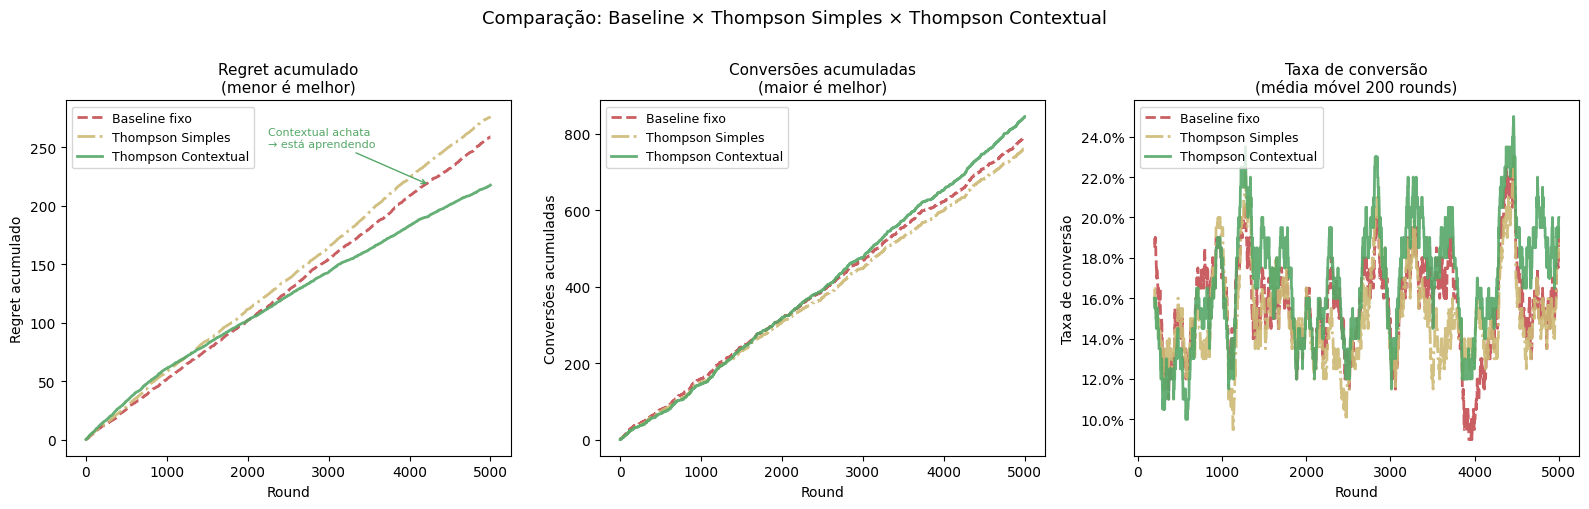

Salvo em reports/comparacao_algoritmos.png


In [10]:
cores_algo  = {"Baseline fixo":"#C44E52", "Thompson Simples":"#CCB974", "Thompson Contextual":"#55A868"}
estilo_algo = {"Baseline fixo":"--",      "Thompson Simples":"-.",       "Thompson Contextual":"-"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparação: Baseline × Thompson Simples × Thompson Contextual", fontsize=13, y=1.01)

# ── Gráfico 1: Regret acumulado ──────────────────────────────────────
ax = axes[0]
for b in bandits:
    nome = b.nome
    ax.plot(resultados[nome]["regret"],
            label=nome, color=cores_algo[nome],
            linestyle=estilo_algo[nome], linewidth=2, alpha=0.9)
ax.set_title("Regret acumulado\n(menor é melhor)", fontsize=11)
ax.set_xlabel("Round")
ax.set_ylabel("Regret acumulado")
ax.legend(fontsize=9)

# Anotação explicativa
ax.annotate("Contextual achata\n→ está aprendendo",
            xy=(N_EVENTOS*0.85, resultados["Thompson Contextual"]["regret"][-1]),
            xytext=(N_EVENTOS*0.45, resultados["Thompson Contextual"]["regret"][-1]*1.15),
            arrowprops=dict(arrowstyle="->", color="#55A868"),
            fontsize=8, color="#55A868")

# ── Gráfico 2: Conversões acumuladas ────────────────────────────────
ax = axes[1]
for b in bandits:
    nome  = b.nome
    acum  = np.cumsum(resultados[nome]["conversoes"])
    ax.plot(acum, label=nome, color=cores_algo[nome],
            linestyle=estilo_algo[nome], linewidth=2, alpha=0.9)
ax.set_title("Conversões acumuladas\n(maior é melhor)", fontsize=11)
ax.set_xlabel("Round")
ax.set_ylabel("Conversões acumuladas")
ax.legend(fontsize=9)

# ── Gráfico 3: Taxa de conversão (janela móvel de 200 rounds) ───────
ax = axes[2]
JANELA = 200
for b in bandits:
    nome = b.nome
    taxa_movel = pd.Series(resultados[nome]["conversoes"]).rolling(JANELA).mean()
    ax.plot(taxa_movel, label=nome, color=cores_algo[nome],
            linestyle=estilo_algo[nome], linewidth=2, alpha=0.9)
ax.set_title(f"Taxa de conversão\n(média móvel {JANELA} rounds)", fontsize=11)
ax.set_xlabel("Round")
ax.set_ylabel("Taxa de conversão")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("reports/comparacao_algoritmos.png", dpi=130, bbox_inches="tight")
plt.show()
print("Salvo em reports/comparacao_algoritmos.png")

## Célula 8 — O que o contextual aprendeu por segmento

Aqui vemos a diferença fundamental: o Thompson contextual mantém aprendizados
separados por segmento. Cada célula da tabela abaixo é um par (alpha, beta) independente.

Segmentos descobertos pelo bandit: 97

Segmento                                 Melhor oferta aprendida        Estimativa
─────────────────────────────────────────────────────────────────────────────────────
admin.__mid__basic                       Empréstimo pessoal pré-aprovado     23.5%
admin.__mid__other                       Cartão de crédito sem anuidade     18.3%
admin.__mid__university                  Cartão de crédito sem anuidade     24.4%
admin.__senior__basic                    Empréstimo pessoal pré-aprovado     50.0%
admin.__senior__other                    Empréstimo pessoal pré-aprovado     33.3%
admin.__senior__university               Seguro de vida                     33.3%
admin.__young__basic                     Seguro de vida                     33.3%
admin.__young__other                     Cartão de crédito sem anuidade     29.6%
admin.__young__university                Cartão de crédito sem anuidade     33.3%
blue-collar__mid__basic                  Empréstimo

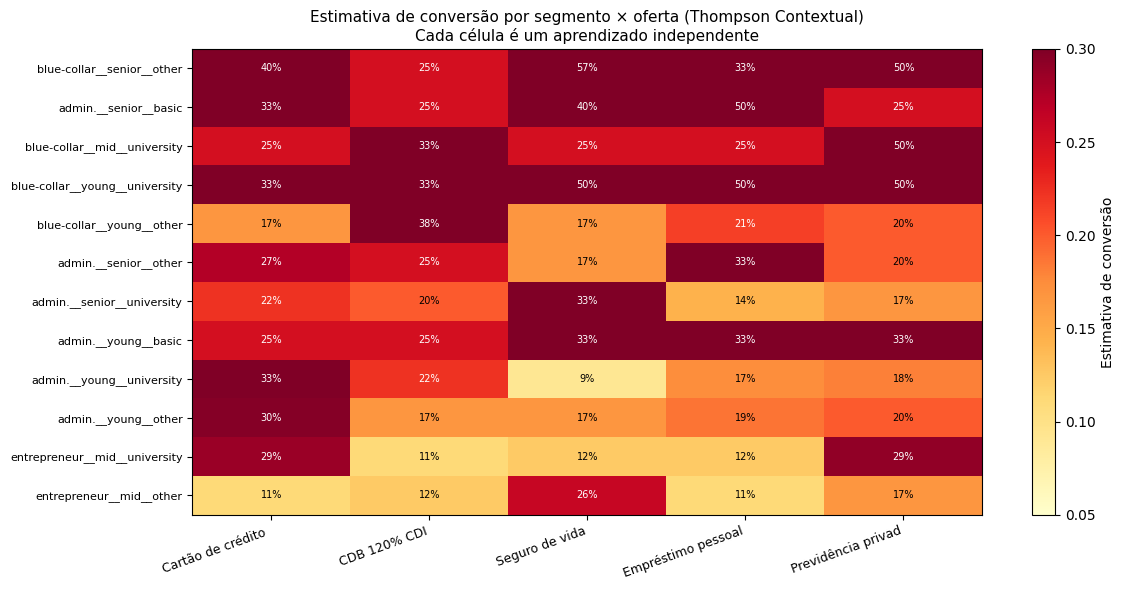

Salvo em reports/heatmap_segmentos.png


In [11]:
tc = bandits[2]  # Thompson Contextual

# Pega os segmentos que apareceram na simulação
segs_presentes = set()
for k in tc.alpha:
    seg_parte = "__".join(k.split("__")[:-1])   # remove o offer_id do final
    segs_presentes.add(seg_parte)

# Para cada segmento, mostra qual oferta o bandit aprendeu a preferir
print(f"Segmentos descobertos pelo bandit: {len(segs_presentes)}")
print()
print(f"{'Segmento':<40} {'Melhor oferta aprendida':<30} {'Estimativa':>10}")
print("─" * 85)

linhas = []
for seg in sorted(segs_presentes)[:20]:  # mostra os 20 primeiros
    estimativas_seg = {}
    for o in OFFER_IDS:
        k = f"{seg}__{o}"
        if k in tc.alpha:
            a = tc.alpha[k]; b = tc.beta[k]
            estimativas_seg[o] = a / (a + b)
    if not estimativas_seg:
        continue
    melhor_o  = max(estimativas_seg, key=estimativas_seg.get)
    melhor_p  = estimativas_seg[melhor_o]
    linhas.append((seg, melhor_o, melhor_p))
    print(f"{seg:<40} {OFFER_MAP[melhor_o]['name']:<30} {melhor_p:>9.1%}")

# Heatmap: estimativa de conversão por segmento × oferta
print()
print("Heatmap de estimativas (Thompson Contextual):")

# Pega segmentos com mais dados para o heatmap
segs_heatmap = [l[0] for l in sorted(linhas, key=lambda x:-x[2])[:12]]
nomes_ofertas = [OFFER_MAP[o]["name"][:18] for o in OFFER_IDS]
matriz = np.zeros((len(segs_heatmap), len(OFFER_IDS)))

for i, seg in enumerate(segs_heatmap):
    for j, o in enumerate(OFFER_IDS):
        k = f"{seg}__{o}"
        if k in tc.alpha:
            a = tc.alpha[k]; b = tc.beta[k]
            matriz[i, j] = a / (a + b)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(matriz, cmap="YlOrRd", aspect="auto", vmin=0.05, vmax=0.30)
ax.set_xticks(range(len(OFFER_IDS)))
ax.set_xticklabels(nomes_ofertas, rotation=20, ha="right", fontsize=9)
ax.set_yticks(range(len(segs_heatmap)))
ax.set_yticklabels([s[:35] for s in segs_heatmap], fontsize=8)
ax.set_title("Estimativa de conversão por segmento × oferta (Thompson Contextual)\nCada célula é um aprendizado independente", fontsize=11)
plt.colorbar(im, ax=ax, label="Estimativa de conversão")

# Anota os valores
for i in range(len(segs_heatmap)):
    for j in range(len(OFFER_IDS)):
        ax.text(j, i, f"{matriz[i,j]:.0%}", ha="center", va="center", fontsize=7,
                color="white" if matriz[i,j] > 0.20 else "black")

plt.tight_layout()
plt.savefig("reports/heatmap_segmentos.png", dpi=130, bbox_inches="tight")
plt.show()
print("Salvo em reports/heatmap_segmentos.png")

## Célula 9 — Visualizar o prior Beta evoluindo

Aqui fica claro por que o contextual é diferente: para o mesmo segmento,
as distribuições Beta ficam mais estreitas e confiantes com o tempo.

Para o Thompson simples, o aprendizado é diluído por todos os perfis.

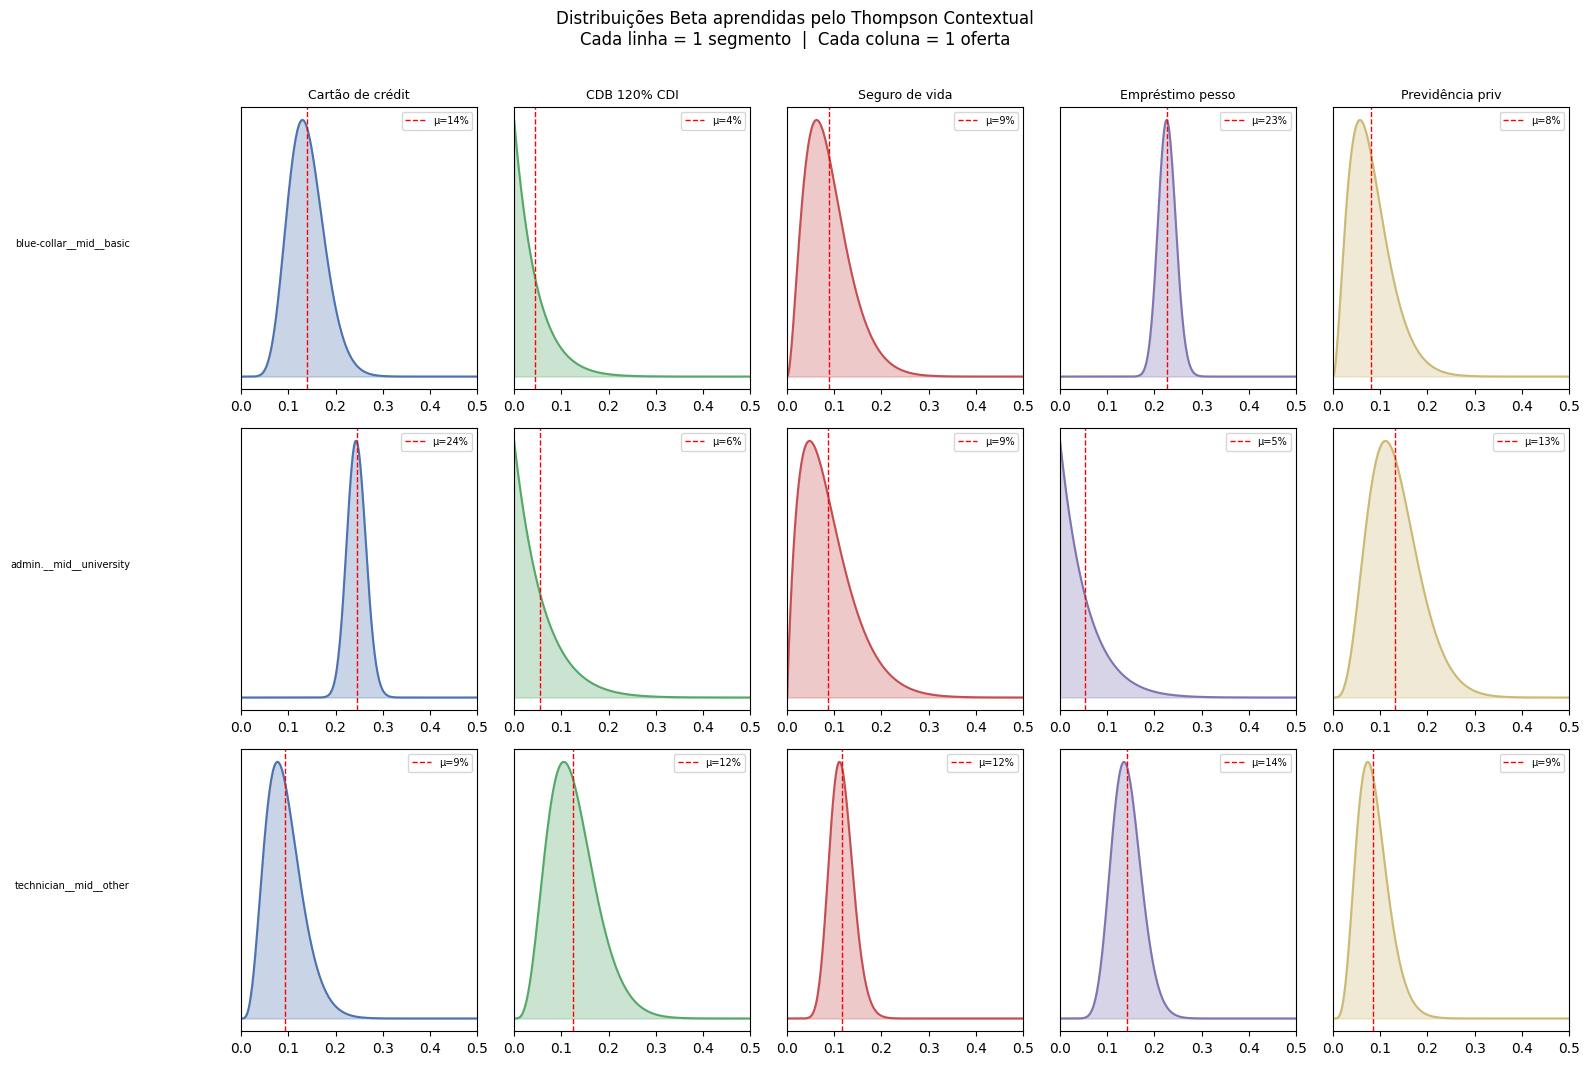

Salvo em reports/betas_por_segmento.png

Interprete: quanto mais estreita a curva, mais confiante o bandit está.
Quanto mais à direita o pico, maior a estimativa de conversão.


In [12]:
tc = bandits[2]  # Thompson Contextual

# Pega 3 segmentos interessantes que tenham dados suficientes
segs_plot = []
for k in tc.alpha:
    seg_parte = "__".join(k.split("__")[:-1])
    # Soma total de observações nesse segmento
    total = sum(tc.alpha[f"{seg_parte}__{o}"] + tc.beta[f"{seg_parte}__{o}"]
                for o in OFFER_IDS if f"{seg_parte}__{o}" in tc.alpha)
    segs_plot.append((seg_parte, total))

segs_plot = sorted(set((s,t) for s,t in segs_plot), key=lambda x:-x[1])[:3]
segs_plot = [s for s,_ in segs_plot]

fig, axes = plt.subplots(len(segs_plot), len(OFFER_IDS),
                          figsize=(16, 3.5 * len(segs_plot)))
fig.suptitle("Distribuições Beta aprendidas pelo Thompson Contextual\n"
             "Cada linha = 1 segmento  |  Cada coluna = 1 oferta", fontsize=12, y=1.01)

x = np.linspace(0, 0.5, 300)

for i, seg in enumerate(segs_plot):
    for j, o in enumerate(OFFER_IDS):
        ax = axes[i][j] if len(segs_plot) > 1 else axes[j]
        k  = f"{seg}__{o}"
        a  = tc.alpha.get(k, 1)
        b  = tc.beta.get(k, 1)
        y  = stats.beta.pdf(x, a, b)
        media = a / (a + b)

        ax.fill_between(x, y, alpha=0.3, color=cores[j])
        ax.plot(x, y, color=cores[j], linewidth=1.5)
        ax.axvline(media, color="red", linestyle="--", linewidth=1,
                   label=f"μ={media:.0%}")
        ax.set_xlim(0, 0.5)
        ax.set_yticks([])
        ax.legend(fontsize=7, loc="upper right")

        if i == 0:
            ax.set_title(OFFER_MAP[o]["name"][:16], fontsize=9)
        if j == 0:
            ax.set_ylabel(seg[:28], fontsize=7, rotation=0, ha="right", labelpad=80)

plt.tight_layout()
plt.savefig("reports/betas_por_segmento.png", dpi=120, bbox_inches="tight")
plt.show()
print("Salvo em reports/betas_por_segmento.png")
print()
print("Interprete: quanto mais estreita a curva, mais confiante o bandit está.")
print("Quanto mais à direita o pico, maior a estimativa de conversão.")

## Célula 10 — Salvar os arquivos finais

Salvamos os eventos gerados pelo **Thompson Contextual** — a melhor política.
Esses arquivos são os entregáveis da Etapa 2.

In [13]:
# Pega os dados registrados do Thompson Contextual
ev_data = resultados["Thompson Contextual"]["events"]
rw_data = resultados["Thompson Contextual"]["rewards"]

df_events  = pd.DataFrame(ev_data)
df_rewards = pd.DataFrame(rw_data)

df_events.to_parquet("data/synthetic_enrichment/offer_events.parquet",    index=False)
df_rewards.to_parquet("data/synthetic_enrichment/delayed_rewards.parquet", index=False)

print("Arquivos salvos:")
print(f"  offer_events.parquet    → {len(df_events):,} linhas")
print(f"  delayed_rewards.parquet → {len(df_rewards):,} linhas")

# Distribuição de rewards
status = df_rewards["reward_status"].value_counts()
print(f"\nDistribuição de rewards:")
for s, n in status.items():
    print(f"  {s:<25} {n:>5,} ({n/len(df_rewards):.1%})")

print("\n── Amostra de offer_events ──")
display(df_events[["event_id","ctx_job","ctx_segmento","offer_id",
                    "p_conversao_real","action_click"]].head())

Arquivos salvos:
  offer_events.parquet    → 5,000 linhas
  delayed_rewards.parquet → 5,000 linhas

Distribuição de rewards:
  observed_negative         4,155 (83.1%)
  observed_positive           736 (14.7%)
  pending                     109 (2.2%)

── Amostra de offer_events ──


,event_id,ctx_job,ctx_segmento,offer_id,p_conversao_real,action_click
0,EVT_0000000,technician,technician__young__other,OFF_005,0.05,False
1,EVT_0000001,entrepreneur,entrepreneur__mid__basic,OFF_003,0.13,False
2,EVT_0000002,blue-collar,blue-collar__mid__basic,OFF_003,0.09,False
3,EVT_0000003,admin.,admin.__mid__university,OFF_005,0.14,False
4,EVT_0000004,admin.,admin.__mid__basic,OFF_004,0.17,True


## Célula 11 — Tabela de métricas finais

A tabela que vai no relatório técnico da Etapa 3.
Mostra o ganho quantitativo de cada abordagem.

In [14]:
print("=" * 65)
print("TABELA COMPARATIVA — ETAPA 3")
print("=" * 65)

linhas_tabela = []
for b in bandits:
    nome  = b.nome
    convs = sum(resultados[nome]["conversoes"])
    taxa  = convs / N_EVENTOS
    reg   = resultados[nome]["regret_acum"]
    reg_medio = reg / N_EVENTOS

    # Regret dos últimos 10% (mostra se ainda está aprendendo)
    ultimo_bloco = resultados[nome]["regret"][int(N_EVENTOS*0.9):]
    reg_final = (ultimo_bloco[-1] - ultimo_bloco[0]) / (N_EVENTOS * 0.1)

    linhas_tabela.append({
        "Algoritmo":          nome,
        "Conversões":         convs,
        "Taxa conversão":     f"{taxa:.2%}",
        "Regret total":       f"{reg:.1f}",
        "Regret médio/round": f"{reg_medio:.4f}",
        "Regret últimos 10%": f"{reg_final:.4f}",
    })

df_tabela = pd.DataFrame(linhas_tabela).set_index("Algoritmo")
display(df_tabela)

# Ganho do contextual sobre o baseline
conv_base = sum(resultados["Baseline fixo"]["conversoes"])
conv_ctx  = sum(resultados["Thompson Contextual"]["conversoes"])
ganho_abs = conv_ctx - conv_base
ganho_rel = (conv_ctx - conv_base) / conv_base

print(f"\nGanho do Thompson Contextual sobre o Baseline:")
print(f"  +{ganho_abs} conversões  (+{ganho_rel:.1%})")
print()
print("Interpretação do 'Regret últimos 10%':")
print("  → Baseline fixo:       alto e constante (não aprende)")
print("  → Thompson Simples:    menor, mas constante (aprendizado parou)")
print("  → Thompson Contextual: o menor (ainda está aprendendo e melhorando)")

TABELA COMPARATIVA — ETAPA 3


,Conversões,Taxa conversão,Regret total,Regret médio/round,Regret últimos 10%
Algoritmo,,,,,
Baseline fixo,793,15.86%,258.9,0.0518,0.0536
Thompson Simples,764,15.28%,276.4,0.0553,0.0508
Thompson Contextual,845,16.90%,217.7,0.0435,0.0335



Ganho do Thompson Contextual sobre o Baseline:
  +52 conversões  (+6.6%)

Interpretação do 'Regret últimos 10%':
  → Baseline fixo:       alto e constante (não aprende)
  → Thompson Simples:    menor, mas constante (aprendizado parou)
  → Thompson Contextual: o menor (ainda está aprendendo e melhorando)


## Célula 12

## Célula 12 — Resumo e próximos passos

Tudo que foi gerado e o que fazer a seguir.

In [13]:
print("=" * 60)
print("ARQUIVOS GERADOS")
print("=" * 60)

arquivos = [
    "data/synthetic_enrichment/offer_catalog.json",
    "data/synthetic_enrichment/offer_events.parquet",
    "data/synthetic_enrichment/delayed_rewards.parquet",
    "reports/comparacao_algoritmos.png",
    "reports/heatmap_segmentos.png",
    "reports/betas_por_segmento.png",
]

for arq in arquivos:
    p = Path(arq)
    status = f"{p.stat().st_size/1024:.1f} KB" if p.exists() else "NÃO ENCONTRADO"
    print(f"  {'✓' if p.exists() else '✗'}  {arq:<55} {status}")

print()
print("PRÓXIMOS PASSOS")
print("-" * 60)
print("  Etapa 4 → Avaliação offline com o golden set")
print("  Etapa 5 → API com FastAPI expondo a decisão do contextual")
print("  Etapa 6 → Arquitetura Azure (onde esse sistema rodaria)")
print("  Etapa 7 → MLOps: retreino, drift, approval gate")

ARQUIVOS GERADOS
  ✓  data/synthetic_enrichment/offer_catalog.json            1.6 KB
  ✓  data/synthetic_enrichment/offer_events.parquet          139.5 KB
  ✓  data/synthetic_enrichment/delayed_rewards.parquet       50.5 KB
  ✓  reports/comparacao_algoritmos.png                       219.3 KB
  ✓  reports/heatmap_segmentos.png                           121.2 KB
  ✓  reports/betas_por_segmento.png                          192.6 KB

PRÓXIMOS PASSOS
------------------------------------------------------------
  Etapa 4 → Avaliação offline com o golden set
  Etapa 5 → API com FastAPI expondo a decisão do contextual
  Etapa 6 → Arquitetura Azure (onde esse sistema rodaria)
  Etapa 7 → MLOps: retreino, drift, approval gate
